# Asset Embeddings: Word2Vec Applied to Portfolios

**Chapter 10: Text Feature Engineering**
**Section Reference**: See Section 10.2 for distributional hypothesis and Word2Vec

**Docker image**: `ml4t-py312`

> **Docker required**: This notebook uses `gensim`, which has no Python 3.14 support.
> Run with:
> ```bash
> docker compose --profile py312 run --rm py312 python 10_text_feature_engineering/02_asset_embeddings.py
> ```

## Purpose
This notebook demonstrates how Word2Vec—the foundational NLP embedding method—
extends beyond text to financial assets. Just as words appearing in similar
contexts have similar meanings, stocks appearing in similar portfolios may
share fundamental characteristics.

We train Word2Vec on institutional 13F holdings data, treating:
- **Portfolios** as sentences (ordered sequences of words)
- **Stocks** as words (tokens in those sentences)
- **Position ordering** as word order (stocks ranked by holding size)

## Learning Objectives
After completing this notebook, you will be able to:
- Apply Word2Vec (skip-gram) to non-text data
- Create "portfolio sentences" from institutional holdings
- Train asset embeddings using gensim Word2Vec
- Find economically similar stocks using embedding distance
- Understand the bridge between NLP and quantitative finance

## Academic Foundation
- **Gabaix, Koijen, Richmond & Yogo (2025)** "Asset Embeddings"
  NBER WP 33651. They show portfolio holdings contain "all relevant information
  for asset pricing" and demonstrate Word2Vec, BERT, and recommender systems
  on institutional holdings data.

## Prerequisites
- Section 10.2 of the chapter (distributional hypothesis, Word2Vec).
- `01_word2vec_training.py` for the Skip-gram mechanics on text.
- 13F bulk 2024Q3 holdings panel under `data/equities/positioning/13f/bulk/2024Q3/`
  (downloaded via `data/equities/positioning/13f_download.py --mode bulk --quarters 2024Q3`).

In [1]:
"""Asset Embeddings: Word2Vec Applied to Portfolios — train stock embeddings from institutional 13F holdings data."""

import json
import warnings
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

from data import load_13f_stock_features
from utils.config import ML4T_DATA_PATH
from utils.paths import get_chapter_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
# Production defaults — Papermill injects overrides for CI
SEED = 42
MAX_INSTITUTIONS = 500  # top-K institutions by holdings count from 2024Q3 bulk filing
QUARTER = "2024Q3"

In [3]:
# Reproducibility — single source of seeds for Python random, NumPy, and (if installed) Torch.
set_global_seeds(SEED)

CONFIG = {
    "random_seed": SEED,
    "embedding_dim": 100,
    "window_size": 5,
    "min_count": 5,
    "sg": 1,  # Skip-gram
    "epochs": 10,
    "workers": 1,  # Single worker for reproducibility (multi-threaded Word2Vec is non-deterministic)
    "benchmark": {
        "position_ranges": [(2, 10), (10, 50), (50, 200)],
        "samples_per_range": 25,
        "bootstrap_iterations": 1000,
    },
}

print("=" * 70)
print("EXPERIMENT CONFIGURATION")
print("=" * 70)
print(json.dumps(CONFIG, indent=2))
print("=" * 70)

EXPERIMENT CONFIGURATION
{
  "random_seed": 42,
  "embedding_dim": 100,
  "window_size": 5,
  "min_count": 5,
  "sg": 1,
  "epochs": 10,
  "workers": 1,
  "benchmark": {
    "position_ranges": [
      [
        2,
        10
      ],
      [
        10,
        50
      ],
      [
        50,
        200
      ]
    ],
    "samples_per_range": 25,
    "bootstrap_iterations": 1000
  }
}


## The Core Insight: Portfolios as Sentences

In NLP, Word2Vec learns that words appearing in similar contexts have similar
meanings. The **skip-gram** objective predicts context words given a target word.

Gabaix et al. (2025) apply this to portfolios:

| NLP Domain | Finance Domain |
|------------|----------------|
| Sentence | Portfolio (stocks ordered by weight) |
| Word | Stock |
| Context window | Nearby positions (similar weights) |
| Similar meaning | Similar investment characteristics |

**Key insight**: Investors assign similar portfolio weights to stocks with
similar characteristics. If AAPL and MSFT often appear as the 2nd and 3rd
largest positions in tech-focused portfolios, they should have similar embeddings.

## Load and Prepare Holdings Data

Every institutional investor managing over $100M must file quarterly 13F-HR
disclosures with the SEC. We use the bulk 2024Q3 filing window and select the
largest 500 institutions by number of holdings — enough portfolios to give
Word2Vec a meaningful co-occurrence signal, while keeping training tractable.

In [4]:
bulk_path = (
    ML4T_DATA_PATH
    / "equities"
    / "positioning"
    / "13f"
    / "bulk"
    / QUARTER
    / "institutional_holdings.parquet"
)
print(f"Loading 13F bulk holdings from {bulk_path.relative_to(ML4T_DATA_PATH)}...")
holdings_full = pl.read_parquet(bulk_path)
print(
    f"Loaded: {holdings_full.height:,} holdings across {holdings_full['cik'].n_unique():,} institutions"
)

# Pick the top-K institutions by holdings count — this favours diversified funds
# whose portfolios provide the richest co-occurrence signal.
institution_sizes = holdings_full.group_by("cik").len().sort("len", descending=True)
selected_ciks = institution_sizes.head(MAX_INSTITUTIONS)["cik"].to_list()
holdings = holdings_full.filter(pl.col("cik").is_in(selected_ciks))

print(
    f"Selected top-{MAX_INSTITUTIONS:,} institutions: {holdings.height:,} holdings, "
    f"{holdings['cusip'].n_unique():,} unique stocks"
)

stock_features = load_13f_stock_features()
cusip_to_name = dict(zip(stock_features["cusip"], stock_features["issuer_name"], strict=False))
# Augment from bulk holdings issuer column for stocks not in the curated stock_features file
for cusip, name in zip(holdings["cusip"].to_list(), holdings["issuer"].to_list(), strict=False):
    if cusip and cusip not in cusip_to_name and name:
        cusip_to_name[cusip] = name
print(f"Stocks with name metadata: {len(cusip_to_name):,}")

Loading 13F bulk holdings from equities/positioning/13f/bulk/2024Q3/institutional_holdings.parquet...
Loaded: 2,863,210 holdings across 7,355 institutions
Selected top-500 institutions: 1,806,379 holdings, 29,746 unique stocks


Stocks with name metadata: 31,603


In [5]:
# Top institutions by total reported holding value.
holdings.group_by("company_name").agg(
    pl.col("value_thousands").sum().alias("total_value_kusd"),
    pl.col("cusip").n_unique().alias("n_positions"),
).sort("total_value_kusd", descending=True).head(10)

company_name,total_value_kusd,n_positions
str,i64,u32
"""VANGUARD GROUP INC""",5584478889705,4351
"""BlackRock, Inc.""",4763739178160,5176
"""STATE STREET CORP""",2457609922723,4296
"""FMR LLC""",1643409181326,5481
"""MORGAN STANLEY""",1379356122725,7927
"""JPMORGAN CHASE & CO""",1311920220697,7424
"""GEODE CAPITAL MANAGEMENT, LLC""",1234954211679,4534
"""BANK OF AMERICA CORP /DE/""",1204606558843,7218
"""GOLDMAN SACHS GROUP INC""",621073615672,4822


## Create Portfolio Sentences

Following Gabaix et al. (2025), we convert each portfolio into a "sentence":
1. Group holdings by institution (CIK)
2. For each institution, order stocks by holding value (descending)
3. The ordered list of stock IDs becomes a "sentence"

This preserves the key insight: stocks with similar portfolio weights
(similar "positions" in the sentence) should have similar embeddings.

In [6]:
# Build one portfolio sentence per institution.
# A single cik can submit multiple 13F-HR filings within a quarter (amendments,
# multiple subsidiaries); collapse to one position per (cik, cusip) by keeping
# the largest reported holding value, then sort positions descending by value.
portfolio_positions = (
    holdings.group_by(["cik", "cusip"])
    .agg(pl.col("value_thousands").max())
    .sort(["cik", "value_thousands"], descending=[False, True])
)

portfolio_sentences = portfolio_positions.group_by("cik", maintain_order=True).agg(
    pl.col("cusip").alias("stocks")
)

sentences = portfolio_sentences["stocks"].to_list()
sentence_lengths = [len(s) for s in sentences]

print(f"Number of portfolios (institutions): {len(sentences):,}")
print(f"Total stock-position pairs:        {sum(sentence_lengths):,}")
print(
    f"Portfolio size — min / median / max: {min(sentence_lengths)} / "
    f"{int(np.median(sentence_lengths))} / {max(sentence_lengths)}"
)

Number of portfolios (institutions): 500
Total stock-position pairs:        965,271
Portfolio size — min / median / max: 82 / 1447 / 22037


In [7]:
# Show the first portfolio's top-10 positions as a readable preview.
preview_cik = portfolio_sentences["cik"][0]
preview_name = holdings.filter(pl.col("cik") == preview_cik)["company_name"].first()
preview_rows = [
    {"position": i + 1, "cusip": cusip, "issuer": cusip_to_name.get(cusip, "Unknown")[:40]}
    for i, cusip in enumerate(sentences[0][:10])
]
print(f"\nPreview portfolio: {preview_name} (CIK {preview_cik}) — top-10 positions")
pl.DataFrame(preview_rows)


Preview portfolio: BANK OF NOVA SCOTIA (CIK 0000009631) — top-10 positions


position,cusip,issuer
i64,str,str
1,"""67066G104""","""NVIDIA CORPORATION"""
2,"""594918104""","""MICROSOFT CORP"""
3,"""891160509""","""TORONTO DOMINION BK ONT"""
4,"""780087102""","""ROYAL BK CDA"""
5,"""037833100""","""APPLE INC"""
6,"""136069101""","""CANADIAN IMPERIAL BANK OF CO"""
7,"""78462F103""","""SPDR S&P 500 ETF TR"""
8,"""063671101""","""BANK MONTREAL QUE"""
9,"""29250N105""","""ENBRIDGE INC"""


## Train Word2Vec on Portfolios

We use gensim's Word2Vec with the **skip-gram** architecture (sg=1),
following the paper's methodology.

Key parameters:
- `vector_size=100`: Embedding dimension
- `window=5`: Context window (positions within 5 of target)
- `sg=1`: Skip-gram (predict context from target word)
- `min_count=5`: Only stocks appearing in 5+ portfolios

In [8]:
# Train Word2Vec
print("Training Word2Vec on portfolio sentences...")

EMBEDDING_DIM = CONFIG["embedding_dim"]
WINDOW_SIZE = CONFIG["window_size"]
MIN_COUNT = CONFIG["min_count"]

model = Word2Vec(
    sentences=sentences,
    vector_size=EMBEDDING_DIM,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    sg=CONFIG["sg"],  # Skip-gram
    workers=CONFIG["workers"],
    epochs=CONFIG["epochs"],
    seed=SEED,
)

print(f"Vocabulary size (stocks): {len(model.wv):,}")
print(f"Embedding dimension: {model.wv.vector_size}")

# How widely each in-vocab stock is held — used downstream to disambiguate
# name searches and to pick the most-held stocks for the t-SNE plot.
occurrence_counts: dict[str, int] = {c: 0 for c in model.wv.key_to_index}
for sentence in sentences:
    for cusip in sentence:
        if cusip in occurrence_counts:
            occurrence_counts[cusip] += 1

Training Word2Vec on portfolio sentences...


Vocabulary size (stocks): 10,887
Embedding dimension: 100


## Why Skip-Gram Works for Portfolios

The skip-gram objective learns embeddings by predicting context words from
a target word. For portfolios:

**Training example**: If Berkshire holds [AAPL, AMEX, KO, BAC, OXY] in order
of position size, and we mask position 3 (KO), we predict KO from its
context (AMEX position 2, BAC position 4).

**Result**: Stocks that appear in similar positions across many portfolios
get similar embeddings—they share investment characteristics valued by
institutional investors.

Gabaix et al. (2025) note: "Investors assign similar portfolio weights to
assets with similar asset embeddings, according to portfolio theory."

## Finding Similar Stocks

With embeddings learned, we can find stocks closest in embedding space.
These are stocks that institutional investors treat similarly.

In [9]:
import re


def neighbours_frame(query: str, top_k: int = 10) -> pl.DataFrame:
    """Return the top-k embedding neighbours of `query` (CUSIP or whole-word name match)."""
    if query in model.wv:
        cusip = query
    else:
        # Whole-word match against issuer name to avoid PINEAPPLE matching "APPLE".
        pattern = re.compile(rf"\b{re.escape(query.upper())}\b")
        matching = [c for c, n in cusip_to_name.items() if n and pattern.search(n.upper())]
        if not matching:
            return pl.DataFrame(
                {
                    "probe": [query],
                    "rank": [0],
                    "cusip": [None],
                    "issuer": ["<not found>"],
                    "similarity": [None],
                }
            )
        # Prefer the in-vocabulary match with the largest holding presence (= most-held stock).
        in_vocab = [c for c in matching if c in model.wv]
        if in_vocab:
            in_vocab.sort(key=lambda c: -occurrence_counts.get(c, 0))
            cusip = in_vocab[0]
        else:
            cusip = matching[0]
    if cusip not in model.wv:
        return pl.DataFrame(
            {
                "probe": [query],
                "rank": [0],
                "cusip": [cusip],
                "issuer": ["<below min_count>"],
                "similarity": [None],
            }
        )
    label = f"{cusip_to_name.get(cusip, 'Unknown')} ({cusip})"
    rows = []
    for rank, (sim_cusip, similarity) in enumerate(
        model.wv.most_similar(cusip, topn=top_k), start=1
    ):
        rows.append(
            {
                "probe": label,
                "rank": rank,
                "cusip": sim_cusip,
                "issuer": cusip_to_name.get(sim_cusip, "Unknown")[:40],
                "similarity": float(similarity),
            }
        )
    return pl.DataFrame(rows)

In [10]:
neighbour_tables = {
    query: neighbours_frame(query, top_k=8)
    for query in ["APPLE", "MICROSOFT", "COCA COLA", "JPMORGAN"]
}

# Concatenate into one display table.
pl.concat(neighbour_tables.values())

probe,rank,cusip,issuer,similarity
str,i64,str,str,f64
"""APPLE INC (037833100)""",1,"""594918104""","""MICROSOFT CORP""",0.942825
"""APPLE INC (037833100)""",2,"""67066G104""","""NVIDIA CORPORATION""",0.934403
"""APPLE INC (037833100)""",3,"""023135106""","""AMAZON COM INC""",0.921583
"""APPLE INC (037833100)""",4,"""78462F103""","""SPDR S&P 500 ETF TR""",0.876225
"""APPLE INC (037833100)""",5,"""922908363""","""VANGUARD INDEX FDS""",0.838898
"""APPLE INC (037833100)""",6,"""02079K305""","""ALPHABET INC""",0.838032
"""APPLE INC (037833100)""",7,"""46090E103""","""INVESCO QQQ TR""",0.837434
"""APPLE INC (037833100)""",8,"""464287200""","""ISHARES TR""",0.835377
"""MICROSOFT CORP (594918104)""",1,"""037833100""","""APPLE INC""",0.942825


## Visualizing Asset Embeddings

We use t-SNE to project the 100-dimensional embeddings to 2D.
Stocks that cluster together share similar institutional ownership patterns.

In [11]:
# Get all embeddings
all_cusips = list(model.wv.key_to_index.keys())
all_embeddings = np.array([model.wv[c] for c in all_cusips])
print(f"Visualizing {len(all_cusips):,} stock embeddings...")

# Take top 500 stocks by occurrence count (computed earlier).
top_cusips = sorted(occurrence_counts.keys(), key=lambda c: occurrence_counts[c], reverse=True)[
    :500
]
# Use dict lookup (O(1)) instead of list.index() (O(n)) for efficiency
cusip_to_idx = {c: i for i, c in enumerate(all_cusips)}
top_indices = [cusip_to_idx[c] for c in top_cusips]
subset_embeddings = all_embeddings[top_indices]
subset_cusips = [all_cusips[i] for i in top_indices]

print(f"Selected {len(subset_cusips)} most widely-held stocks for visualization")

Visualizing 10,887 stock embeddings...
Selected 500 most widely-held stocks for visualization


In [12]:
# t-SNE projection
print("Running t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
embeddings_2d = tsne.fit_transform(subset_embeddings)

Running t-SNE dimensionality reduction...


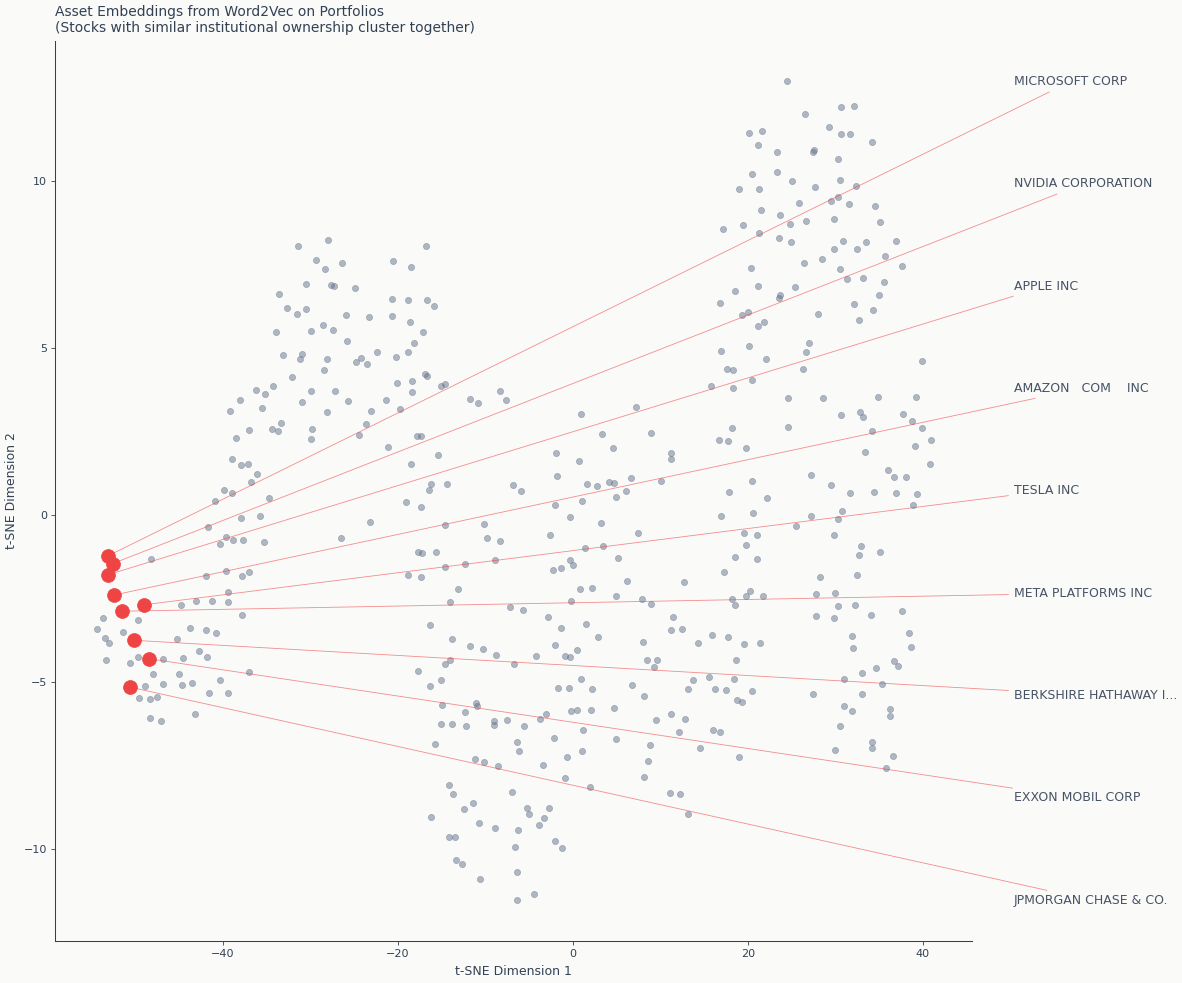

In [13]:
# Visualize
fig, ax = plt.subplots(figsize=(12, 10))

# Plot all points
ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5, s=20, c="#64748b")

# Highlight recognizable stocks
highlight_keywords = [
    "APPLE",
    "MICROSOFT",
    "NVIDIA",
    "AMAZON",
    "GOOGLE",
    "META",
    "TESLA",
    "BERKSHIRE",
    "JPMORGAN",
    "EXXON",
]
highlighted = [
    (i, cusip_to_name.get(c, ""))
    for i, c in enumerate(subset_cusips)
    if cusip_to_name.get(c, "")
    and any(kw in cusip_to_name.get(c, "").upper() for kw in highlight_keywords)
]
# Order labels top-to-bottom by 2D y-coordinate, then fan them out to the right
# with leader lines so they no longer stack at the highlight cluster.
highlighted.sort(key=lambda t: -embeddings_2d[t[0], 1])
x_max = embeddings_2d[:, 0].max()
y_min, y_max = embeddings_2d[:, 1].min(), embeddings_2d[:, 1].max()
n_h = max(len(highlighted), 1)
for slot, (i, name) in enumerate(highlighted):
    x_pt, y_pt = embeddings_2d[i, 0], embeddings_2d[i, 1]
    ax.scatter(x_pt, y_pt, s=100, c="#ef4444", zorder=5)
    short_name = name[:20] + "..." if len(name) > 20 else name
    label_x = x_max + 0.10 * (x_max - embeddings_2d[:, 0].min())
    label_y = y_max - slot * (y_max - y_min) / max(n_h - 1, 1)
    ax.annotate(
        short_name,
        xy=(x_pt, y_pt),
        xytext=(label_x, label_y),
        fontsize=9,
        alpha=0.9,
        ha="left",
        va="center",
        arrowprops=dict(arrowstyle="-", color="#ef4444", lw=0.6, alpha=0.6),
    )

ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.set_title(
    "Asset Embeddings from Word2Vec on Portfolios\n"
    "(Stocks with similar institutional ownership cluster together)"
)
plt.tight_layout()
plt.show()

## Managed Portfolio Benchmark: Masked Asset Prediction

This is the key empirical test from Gabaix et al. (2025). The benchmark asks:
**Can embeddings predict which stock belongs in a portfolio?**

Methodology:
1. For each test portfolio, mask one position (e.g., the 5th largest holding)
2. Use the surrounding context to predict which stock was masked
3. Report accuracy@k: Is the true stock in the top k predictions?

This directly tests the Word2Vec hypothesis: stocks appearing in similar
portfolio positions should have similar embeddings.

In [14]:
# Managed Portfolio Benchmark Introduction
print("=" * 70)
print("MANAGED PORTFOLIO BENCHMARK: Masked Asset Prediction")
print("=" * 70)

MANAGED PORTFOLIO BENCHMARK: Masked Asset Prediction


### Predict Masked Asset
Given a portfolio with one position masked, use surrounding context to predict the hidden stock.

In [15]:
def predict_masked_asset(portfolio: list, mask_position: int, model, window: int = 5) -> list:
    """
    Predict the masked asset using context from surrounding positions.

    Args:
        portfolio: List of CUSIPs ordered by holding value
        mask_position: Index of position to mask (0-indexed)
        model: Trained Word2Vec model
        window: Context window size

    Returns:
        List of (cusip, score) tuples for top predictions
    """
    if mask_position >= len(portfolio):
        return []

    # Get context window (positions around the masked one)
    start = max(0, mask_position - window)
    end = min(len(portfolio), mask_position + window + 1)

    context = []
    for i in range(start, end):
        if i != mask_position and portfolio[i] in model.wv:
            context.append(portfolio[i])

    if not context:
        return []

    # Predict using context - average context embeddings and find similar
    try:
        predictions = model.wv.most_similar(positive=context, topn=100)
        return predictions
    except KeyError:
        return []

### HitRecord and Benchmark Evaluation
Track per-sample prediction outcomes and aggregate benchmark metrics.

In [16]:
@dataclass
class HitRecord:
    """Record of a single masked asset prediction outcome."""

    bucket: str  # Position range label
    hit1: int  # 1 if rank <= 1, else 0
    hit5: int  # 1 if rank <= 5, else 0
    hit10: int  # 1 if rank <= 10, else 0
    rr: float  # Reciprocal rank (1/rank if found, 0 otherwise)

### Run Benchmark Evaluation
Sample masked positions across portfolios and compute accuracy metrics.

In [17]:
def evaluate_benchmark(
    portfolios: list,
    model,
    position_ranges: list = [(2, 10), (10, 50), (50, 200)],
    samples_per_range: int = 100,
) -> tuple[dict, list[HitRecord]]:
    """
    Run the masked asset prediction benchmark with robust sampling.

    Since we have few portfolios but many stocks per portfolio, we sample
    multiple masked positions from each portfolio for statistical power.

    Args:
        portfolios: List of portfolio sentences
        model: Trained Word2Vec model
        position_ranges: List of (start, end) tuples defining position ranges to test
        samples_per_range: Number of masked positions to sample per range

    Returns:
        Tuple of (aggregate_metrics_dict, list_of_hit_records)
        - aggregate_metrics: Dictionary with accuracy metrics by position range
        - hit_records: Per-sample outcomes for correct bootstrap CI computation
    """
    # Collect per-sample hit records for proper bootstrap
    hit_records: list[HitRecord] = []

    np.random.seed(SEED)

    for portfolio in portfolios:
        for start, end in position_ranges:
            label = f"pos_{start + 1}-{end}"

            # Get valid positions in this range
            valid_positions = [
                i for i in range(start, min(end, len(portfolio))) if portfolio[i] in model.wv
            ]

            if not valid_positions:
                continue

            # Sample positions to test
            n_samples = min(samples_per_range, len(valid_positions))
            test_positions = np.random.choice(valid_positions, n_samples, replace=False)

            for mask_pos in test_positions:
                true_asset = portfolio[mask_pos]

                predictions = predict_masked_asset(portfolio, mask_pos, model)
                if not predictions:
                    continue

                # Find rank of true asset
                pred_cusips = [p[0] for p in predictions]
                if true_asset in pred_cusips:
                    rank = pred_cusips.index(true_asset) + 1
                    hit_records.append(
                        HitRecord(
                            bucket=label,
                            hit1=int(rank <= 1),
                            hit5=int(rank <= 5),
                            hit10=int(rank <= 10),
                            rr=1.0 / rank,
                        )
                    )
                else:
                    hit_records.append(HitRecord(bucket=label, hit1=0, hit5=0, hit10=0, rr=0.0))

    # Aggregate metrics from raw records
    results = {}
    for start, end in position_ranges:
        label = f"pos_{start + 1}-{end}"
        bucket_records = [r for r in hit_records if r.bucket == label]
        n = len(bucket_records)
        if n > 0:
            results[label] = {
                "hits@1": sum(r.hit1 for r in bucket_records) / n,
                "hits@5": sum(r.hit5 for r in bucket_records) / n,
                "hits@10": sum(r.hit10 for r in bucket_records) / n,
                "mrr": sum(r.rr for r in bucket_records) / n,
                "total": n,
            }
        else:
            results[label] = {"hits@1": 0, "hits@5": 0, "hits@10": 0, "mrr": 0, "total": 0}

    return results, hit_records

In [18]:
# Run the benchmark
SAMPLES_PER_RANGE = CONFIG["benchmark"]["samples_per_range"]
POSITION_RANGES = CONFIG["benchmark"]["position_ranges"]
print("\nRunning masked asset prediction benchmark...")
print(f"Testing position ranges {POSITION_RANGES}")
print(f"Sampling {SAMPLES_PER_RANGE} positions per range from each portfolio.\n")

benchmark_results, hit_records = evaluate_benchmark(
    sentences,
    model,
    position_ranges=POSITION_RANGES,
    samples_per_range=SAMPLES_PER_RANGE,
)

# Display results
benchmark_table = pl.DataFrame(
    [
        {
            "position_range": label,
            "hits_at_1": metrics["hits@1"],
            "hits_at_5": metrics["hits@5"],
            "hits_at_10": metrics["hits@10"],
            "mrr": metrics["mrr"],
            "n": metrics["total"],
        }
        for label, metrics in benchmark_results.items()
    ]
)
benchmark_table


Running masked asset prediction benchmark...
Testing position ranges [(2, 10), (10, 50), (50, 200)]
Sampling 25 positions per range from each portfolio.



position_range,hits_at_1,hits_at_5,hits_at_10,mrr,n
str,f64,f64,f64,f64,i64
"""pos_3-10""",0.195411,0.346193,0.432173,0.271056,3966
"""pos_11-50""",0.014337,0.06656,0.120465,0.04963,12485
"""pos_51-200""",0.00048,0.00512,0.01632,0.008578,12500


In [19]:
# Compare to random baseline with bootstrap confidence intervals
print("\n" + "=" * 70)
print("COMPARISON TO RANDOM BASELINE (with Bootstrap CI)")
print("=" * 70)

vocab_size = len(model.wv)
random_hits1 = 1 / vocab_size
random_hits5 = 5 / vocab_size
random_hits10 = 10 / vocab_size

print(f"\nVocabulary size: {vocab_size:,} stocks")
print("\nRandom baseline (analytical):")
print(f"  Hits@1:  {random_hits1:.4%} (= 1/{vocab_size:,})")
print(f"  Hits@5:  {random_hits5:.4%} (= 5/{vocab_size:,})")
print(f"  Hits@10: {random_hits10:.4%} (= 10/{vocab_size:,})")


COMPARISON TO RANDOM BASELINE (with Bootstrap CI)

Vocabulary size: 10,887 stocks

Random baseline (analytical):
  Hits@1:  0.0092% (= 1/10,887)
  Hits@5:  0.0459% (= 5/10,887)
  Hits@10: 0.0919% (= 10/10,887)


### Bootstrap Confidence Intervals
Compute CIs for benchmark metrics using raw per-sample hit records.

In [20]:
def bootstrap_metrics(
    hit_records: list[HitRecord], n_iterations: int = 1000, confidence: float = 0.95
) -> dict:
    """
    Compute bootstrap confidence intervals for benchmark metrics.

    Uses raw per-sample hit records for correct uncertainty estimation,
    preserving the actual sampling distribution rather than reconstructing
    from aggregate rates.

    Args:
        hit_records: List of HitRecord with per-sample outcomes
        n_iterations: Number of bootstrap samples
        confidence: Confidence level (default 95%)

    Returns:
        Dictionary with mean and CI for each position bucket
    """
    alpha = (1 - confidence) / 2

    # Group records by bucket
    buckets = {}
    for record in hit_records:
        if record.bucket not in buckets:
            buckets[record.bucket] = []
        buckets[record.bucket].append(record)

    bootstrap_stats = {}
    for label, records in buckets.items():
        if not records:
            continue

        # Extract raw hit5 indicators (actual per-sample outcomes)
        hits5_indicators = np.array([r.hit5 for r in records])
        n = len(hits5_indicators)

        # Bootstrap resampling on raw indicators
        boot_means = []
        for _ in range(n_iterations):
            sample_idx = np.random.choice(n, size=n, replace=True)
            boot_means.append(np.mean(hits5_indicators[sample_idx]))

        # Compute percentile CI
        lower = np.percentile(boot_means, alpha * 100)
        upper = np.percentile(boot_means, (1 - alpha) * 100)

        bootstrap_stats[label] = {
            "mean": np.mean(hits5_indicators),
            "ci_lower": lower,
            "ci_upper": upper,
            "n": n,
        }

    return bootstrap_stats


print(
    f"\nBootstrap confidence intervals ({CONFIG['benchmark']['bootstrap_iterations']} iterations):"
)
boot_stats = bootstrap_metrics(
    hit_records, n_iterations=CONFIG["benchmark"]["bootstrap_iterations"]
)

for label, stats in boot_stats.items():
    print(
        f"  {label}: Hits@5 = {stats['mean']:.1%} "
        f"[95% CI: {stats['ci_lower']:.1%} - {stats['ci_upper']:.1%}] "
        f"(n={stats['n']})"
    )

# Compute improvement over random
avg_hits5 = np.mean([m["hits@5"] for m in benchmark_results.values() if m["total"] > 0])
improvement = avg_hits5 / random_hits5

# CI on improvement
avg_ci_lower = np.mean([s["ci_lower"] for s in boot_stats.values()])
avg_ci_upper = np.mean([s["ci_upper"] for s in boot_stats.values()])
improvement_lower = avg_ci_lower / random_hits5
improvement_upper = avg_ci_upper / random_hits5

print("\nSUMMARY")
print(f"  Word2Vec Hits@5 (avg over position buckets): {avg_hits5:.1%}")
print(f"  Random baseline Hits@5:                      {random_hits5:.4%}")
print(
    f"  Improvement over random: {improvement:.0f}x [95% CI: {improvement_lower:.0f}x – {improvement_upper:.0f}x]"
)


Bootstrap confidence intervals (1000 iterations):


  pos_3-10: Hits@5 = 34.6% [95% CI: 33.3% - 36.2%] (n=3966)
  pos_11-50: Hits@5 = 6.7% [95% CI: 6.2% - 7.1%] (n=12485)
  pos_51-200: Hits@5 = 0.5% [95% CI: 0.4% - 0.6%] (n=12500)

SUMMARY
  Word2Vec Hits@5 (avg over position buckets): 13.9%
  Random baseline Hits@5:                      0.0459%
  Improvement over random: 303x [95% CI: 289x – 319x]


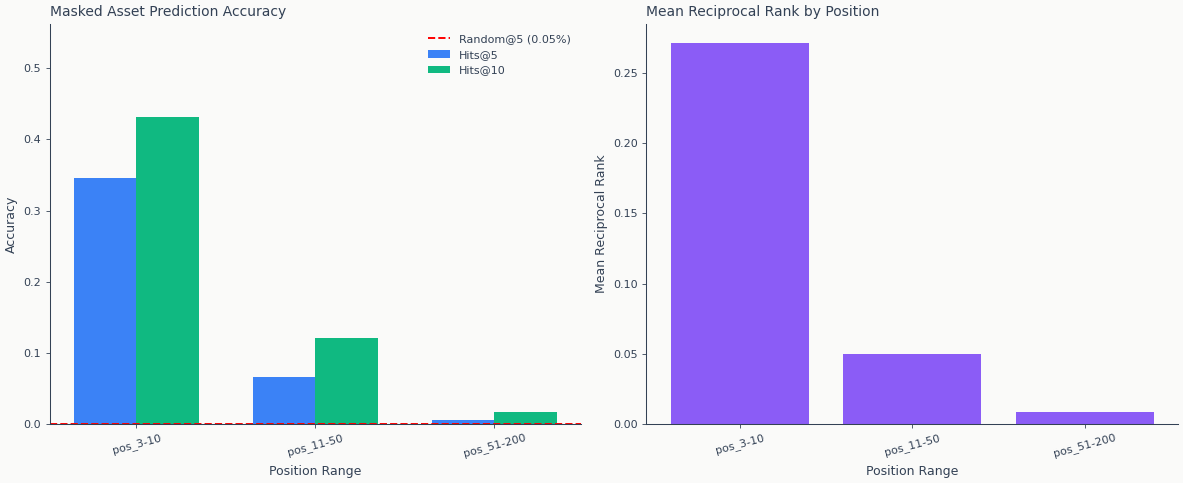

In [21]:
# Visualize benchmark results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Accuracy by position range
labels = list(benchmark_results.keys())
hits5 = [m["hits@5"] for m in benchmark_results.values()]
hits10 = [m["hits@10"] for m in benchmark_results.values()]

ax = axes[0]
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width / 2, hits5, width, label="Hits@5", color="#3b82f6")
ax.bar(x + width / 2, hits10, width, label="Hits@10", color="#10b981")
ax.axhline(y=random_hits5, color="red", linestyle="--", label=f"Random@5 ({random_hits5:.2%})")
ax.set_xlabel("Position Range")
ax.set_ylabel("Accuracy")
ax.set_title("Masked Asset Prediction Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.legend()
ax.set_ylim(0, max(max(hits10), 0.01) * 1.3)

# Right: MRR by position range
mrrs = [m["mrr"] for m in benchmark_results.values()]
ax = axes[1]
ax.bar(x, mrrs, color="#8b5cf6")
ax.set_xlabel("Position Range")
ax.set_ylabel("Mean Reciprocal Rank")
ax.set_title("Mean Reciprocal Rank by Position")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)

plt.tight_layout()
plt.show()

## Benchmark Interpretation

- **Hits@k**: fraction of times the true masked stock appears in the top-k
  nearest neighbours of the surrounding context.
- **MRR**: mean reciprocal rank of the true stock; bounded by 1.

Two patterns are worth checking against the table above:

1. The position-bucket effect — top positions (the largest holdings) are more
   consistently held across funds, so their context is predictive; lower
   positions are noisier and Hits@k typically falls.
2. The lift over the analytical random baseline (`5 / vocab_size`) — even a
   single-quarter Word2Vec model on 500 portfolios should be one-to-two
   orders of magnitude above random, well outside the bootstrap CI.

This is the same masked-asset benchmark Gabaix et al. (2025)
use to compare Word2Vec, BERT, and recommender-system embeddings.

## Connection to the Paper

Gabaix et al. (2025) compare three embedding methods:

1. **Recommender Systems (RS)**: PCA on investor-asset holdings matrix
2. **Word2Vec**: Skip-gram on portfolio sentences (what we did here)
3. **BERT**: Transformer with attention for contextualized embeddings

Their key findings:
- **4D embeddings explain >50% of valuation variation** (vs 15% for characteristics)
- Word2Vec excels at the **managed portfolio benchmark** (predicting masked assets)
- Text embeddings from OpenAI/Cohere perform **poorly**—portfolio data captures
  information that company descriptions cannot

Our implementation demonstrates the Word2Vec approach, showing how NLP methods
transfer directly to financial data.

## Applications

Asset embeddings enable practical applications:

### 1. Stock Substitution
Find replacement stocks when constraints prevent trading the original.

### 2. Portfolio Diversification
Measure true diversification: positions far apart in embedding space
are more diversified than those close together.

### 3. Crowding Detection
Track how embeddings evolve; stocks moving toward dense regions
may face crowding-related headwinds.

### 4. Risk Modeling
Embedding similarity captures relationships not visible in returns covariance.

In [22]:
# Demo: Portfolio diversification analysis
print("\nPortfolio Diversification Analysis")
print("=" * 50)

# Take 5 random widely-held stocks
sample_cusips = np.random.choice(subset_cusips[:100], size=5, replace=False)
sample_names = [cusip_to_name.get(c, "Unknown")[:25] for c in sample_cusips]

print("Sample portfolio:")
for name in sample_names:
    print(f"  - {name}")

# Compute pairwise similarities
sims = []
for i, c1 in enumerate(sample_cusips):
    for c2 in sample_cusips[i + 1 :]:
        sims.append(model.wv.similarity(c1, c2))

print(f"\nAverage pairwise similarity: {np.mean(sims):.3f}")
print("(Lower = more diversified in terms of institutional ownership patterns)")


Portfolio Diversification Analysis
Sample portfolio:
  - EXXON MOBIL CORP
  - CONOCOPHILLIPS
  - FREEPORT-MCMORAN INC
  - MCKESSON CORP
  - PEPSICO INC

Average pairwise similarity: 0.648
(Lower = more diversified in terms of institutional ownership patterns)


## Key Takeaways

1. **Word2Vec applies beyond text**: Portfolios as sentences, stocks as words.

2. **Skip-gram learns from position ordering**: Stocks at similar portfolio
   positions (by weight) get similar embeddings.

3. **Gabaix et al. (2025) frame holdings as informationally sufficient** for
   asset pricing. This notebook does not reproduce that proof; it
   implements one of the paper's embedding methods (Skip-gram on portfolio
   sentences) and reproduces the masked-asset benchmark protocol on a
   single-quarter 13F snapshot of ~500 portfolios. The notebook's own
   measurements are the Hits@k and MRR values printed above, with
   bootstrap CIs and the vs-random improvement multiple.

4. **Paper-reported comparisons (not measured here)**: Gabaix et al. (2025)
   report 4D embeddings explaining >50% of valuation variation versus
   ~15% for characteristics, and report that text-only embeddings from
   OpenAI/Cohere underperform portfolio-derived embeddings on the same
   benchmark. These numbers come from the paper, not from this notebook's
   benchmark run; see the paper for the full set of comparisons.

5. **Practical applications**: Stock substitution, diversification,
   crowding detection, and enhanced risk models.

In [23]:
# Save model and results to output directory
chapter_dir = get_chapter_dir(10)
output_dir = chapter_dir / "output" / "asset_embeddings"
output_dir.mkdir(parents=True, exist_ok=True)
model_path = output_dir / "asset_word2vec.model"
model.save(str(model_path))
print(f"\nModel saved to: {model_path}")


Model saved to: 10_text_feature_engineering/output/asset_embeddings/asset_word2vec.model


In [24]:
# JSON artifact for reproducibility verification
results_artifact = {
    "config": CONFIG,
    "data_summary": {
        "portfolios": len(sentences),
        "vocabulary_size": len(model.wv),
        "embedding_dim": EMBEDDING_DIM,
        "min_count": MIN_COUNT,
    },
    "benchmark_results": {
        label: {
            "hits_at_5": m["hits@5"],
            "hits_at_10": m["hits@10"],
            "mrr": m["mrr"],
            "n_samples": m["total"],
        }
        for label, m in benchmark_results.items()
    },
    "random_baseline": {
        "hits_at_5": random_hits5,
        "hits_at_10": random_hits10,
        "vocab_size": vocab_size,
    },
    "bootstrap_ci": {
        label: {
            "mean": stats["mean"],
            "ci_lower_95": stats["ci_lower"],
            "ci_upper_95": stats["ci_upper"],
            "n": stats["n"],
        }
        for label, stats in boot_stats.items()
    },
    "improvement_over_random": {
        "point_estimate": improvement,
        "ci_lower_95": improvement_lower,
        "ci_upper_95": improvement_upper,
    },
}

In [25]:
json_file = output_dir / "results.json"
with open(json_file, "w") as f:
    json.dump(results_artifact, f, indent=2)

In [26]:
# Markdown summary
results_file = output_dir / "results.md"
with open(results_file, "w") as f:
    f.write("# Asset Embeddings Results\n\n")
    f.write("## Method\n")
    f.write("- Word2Vec (skip-gram) trained on portfolio sentences\n")
    f.write("- Portfolios = sentences, stocks = words, position order = word order\n")
    f.write(f"- Random seed: {SEED}\n\n")
    f.write("## Data Summary\n")
    f.write(f"- Portfolios (institutions): {len(sentences):,}\n")
    f.write(f"- Vocabulary (stocks): {len(model.wv):,}\n")
    f.write(f"- Embedding dimension: {EMBEDDING_DIM}\n")
    f.write(f"- Context window: {WINDOW_SIZE}\n")
    f.write(f"- Min count (stock must appear in N portfolios): {MIN_COUNT}\n\n")
    f.write("## Managed Portfolio Benchmark\n")
    f.write("Masked asset prediction (paper's key test for Word2Vec):\n\n")
    f.write("| Position Range | Hits@5 | 95% CI | Hits@10 | MRR | N |\n")
    f.write("|----------------|--------|--------|---------|-----|---|\n")
    for label, m in benchmark_results.items():
        ci = boot_stats.get(label, {})
        ci_str = f"[{ci.get('ci_lower', 0):.1%}-{ci.get('ci_upper', 0):.1%}]" if ci else "N/A"
        f.write(
            f"| {label} | {m['hits@5']:.1%} | {ci_str} | {m['hits@10']:.1%} | {m['mrr']:.3f} | {m['total']} |\n"
        )
    f.write("\n### Random Baseline Comparison\n")
    f.write(f"- Vocabulary size: {vocab_size:,} stocks\n")
    f.write(f"- Random Hits@5: {random_hits5:.4%} (= 5/{vocab_size:,})\n")
    f.write(
        f"- **Improvement over random: {improvement:.0f}x** [95% CI: {improvement_lower:.0f}x - {improvement_upper:.0f}x]\n\n"
    )
    f.write("## Key Insight\n")
    f.write("Word2Vec on portfolio data learns stock representations that capture\n")
    f.write("institutional investor behavior. The masked asset prediction benchmark\n")
    f.write("demonstrates the method's practical utility for portfolio construction.\n\n")
    f.write("Reference: Gabaix et al. (2025).\n")

print("Results saved to:")
print(f"  - {results_file}")
print(f"  - {json_file}")

Results saved to:
  - 10_text_feature_engineering/output/asset_embeddings/results.md
  - 10_text_feature_engineering/output/asset_embeddings/results.json
